# Task 3: Deep Learning with Explainability

**Model:** LSTM for traffic volume prediction (since this data is naturally sequential/hourly time series).

**Explainability:**   SHAP's `TreeExplainer` is exact and fast for tree ensembles, giving reliable global and local feature attributions that are broadly representative of what drives traffic volume, even though the LSTM and Random Forest are architecturally different models.

## 1. Imports

In [1]:
# pip install tensorflow shap   (not in the standard scientific stack)
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap

RANDOM_STATE = 42

## 2. Logging setup

A named logger (logging.getLogger("task1_models")) is used instead of the root logger, with propagate = False, so this doesn't collide with Jupyter's own logging setup or double-print.

In [2]:
logger = logging.getLogger("task3_models")


def setup_logging():
    if logger.handlers:
        return
    logger.setLevel(logging.DEBUG)
    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    fh = logging.FileHandler("pipeline.log", mode="a", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(fmt)

    ch = logging.StreamHandler()
    ch.setLevel(logging.INFO)
    ch.setFormatter(fmt)

    logger.addHandler(fh)
    logger.addHandler(ch)
    logger.propagate = False


setup_logging()
logger.info("Logging initialised")

2026-09-23 22:23:00 | INFO | task3_models | Logging initialised


## 3. Load the feature-engineered dataset

In [3]:
FEATURES_PATH = "Features_Metro_Interstate_Traffic_Volume.csv"

df = pd.read_csv(FEATURES_PATH, parse_dates=["date_time"])
logger.info("Loaded %s rows, %s columns from %s", len(df), df.shape[1], FEATURES_PATH)
df.head()

2026-09-23 22:23:01 | INFO | task3_models | Loaded 48187 rows, 38 columns from Features_Metro_Interstate_Traffic_Volume.csv


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,month,...,is_precipitation,total_precipitation,is_overcast,is_clear,is_severe_weather,temp_c_zscore,traffic_volume_zscore,temp_c_minmax,traffic_volume_minmax,congestion_category
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,10,...,0,0.0,0,0,0,0.530410,1.150193,0.929726,0.761676,High
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,...,0,0.0,0,0,0,0.611377,0.632315,0.933209,0.620330,Medium
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,10,...,0,0.0,1,0,0,0.627871,0.758639,0.933918,0.654808,High
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,10,...,0,0.0,1,0,0,0.669104,0.888990,0.935692,0.690385,High
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,10,...,0,0.0,0,0,0,0.744823,0.834635,0.938949,0.675549,High


## 4. LSTM: sequential traffic volume prediction

### 4.1 Build sliding-window sequences

The model predicts the **next hour's** `traffic_volume` from the previous `LOOKBACK` hours of a small multivariate feature set (the target itself plus a few features known to matter: cyclical hour, weekend flag, temperature, precipitation). Data is sorted chronologically first, and the train/test split is **chronological, not random** — shuffling would leak future information into training, which is invalid for time series.

In [4]:
FEATURE_COLS = ["traffic_volume", "hour_sin", "hour_cos", "is_weekend", "temp_c", "is_precipitation"]
TARGET_COL = "traffic_volume"
LOOKBACK = 24  # hours of history used to predict the next hour

df_sorted = df.sort_values("date_time").reset_index(drop=True)
data = df_sorted[FEATURE_COLS].dropna().reset_index(drop=True)
logger.info("Sequence data prepared: %s rows, %s features", len(data), len(FEATURE_COLS))

# --- Chronological split: first 80% train, last 20% test (no shuffling) ---
split_idx = int(len(data) * 0.8)
train_raw = data.iloc[:split_idx]
test_raw = data.iloc[split_idx:]
logger.info("Chronological split: %s train rows, %s test rows", len(train_raw), len(test_raw))

# --- Scale using train-only statistics (avoid leakage) ---
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)
target_idx = FEATURE_COLS.index(TARGET_COL)


def make_sequences(arr, lookback, target_idx):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i - lookback:i, :])
        y.append(arr[i, target_idx])
    return np.array(X), np.array(y)


X_train, y_train = make_sequences(train_scaled, LOOKBACK, target_idx)

# Prepend the last LOOKBACK train rows onto test so the first test predictions
# have real historical context instead of losing LOOKBACK rows at the split boundary
test_scaled_with_context = np.vstack([train_scaled[-LOOKBACK:], test_scaled])
X_test, y_test = make_sequences(test_scaled_with_context, LOOKBACK, target_idx)

logger.info("Sequences built: X_train %s, X_test %s", X_train.shape, X_test.shape)

2026-09-23 22:23:01 | INFO | task3_models | Sequence data prepared: 48187 rows, 6 features
2026-09-23 22:23:01 | INFO | task3_models | Chronological split: 38549 train rows, 9638 test rows
2026-09-23 22:23:01 | INFO | task3_models | Sequences built: X_train (38525, 24, 6), X_test (9638, 24, 6)


### 4.2 Build and train the LSTM

In [5]:
model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, len(FEATURE_COLS)), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1),
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

C:\Users\krmee\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)
logger.info("LSTM training complete: %s epochs run", len(history.history["loss"]))

Epoch 1/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0185 - mae: 0.0983 - val_loss: 0.0069 - val_mae: 0.0629
Epoch 2/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0083 - mae: 0.0649 - val_loss: 0.0043 - val_mae: 0.0474
Epoch 3/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0069 - mae: 0.0573 - val_loss: 0.0041 - val_mae: 0.0447
Epoch 4/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0063 - mae: 0.0540 - val_loss: 0.0034 - val_mae: 0.0411
Epoch 5/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0059 - mae: 0.0518 - val_loss: 0.0034 - val_mae: 0.0409
Epoch 6/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0056 - mae: 0.0501 - val_loss: 0.0037 - val_mae: 0.0425
Epoch 7/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0055 - mae: 0.0490 - val_loss: 0.0032 - val_mae: 0.0388
Epoch 8/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0053 - mae: 0.0483 - val_loss: 0.0033 - val_mae: 0.0407
Epoch 9/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 8s 

2026-09-23 22:26:49 | INFO | task3_models | LSTM training complete: 24 epochs run


### 4.3 Evaluate (inverse-transform back to real traffic_volume units)

In [7]:
def inverse_transform_target(scaled_values, scaler, target_idx, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx]


y_test_actual = inverse_transform_target(y_test, scaler, target_idx, len(FEATURE_COLS))
y_pred_scaled = model.predict(X_test).flatten()
y_pred_actual = inverse_transform_target(y_pred_scaled, scaler, target_idx, len(FEATURE_COLS))

lstm_mae = mean_absolute_error(y_test_actual, y_pred_actual)
lstm_r2 = r2_score(y_test_actual, y_pred_actual)
logger.info("LSTM test MAE: %.2f, R2: %.4f", lstm_mae, lstm_r2)
logger.info(f"LSTM — MAE: {lstm_mae:.2f}, R2: {lstm_r2:.4f}")

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


2026-09-23 22:26:52 | INFO | task3_models | LSTM test MAE: 237.23, R2: 0.9665
2026-09-23 22:26:52 | INFO | task3_models | LSTM — MAE: 237.23, R2: 0.9665


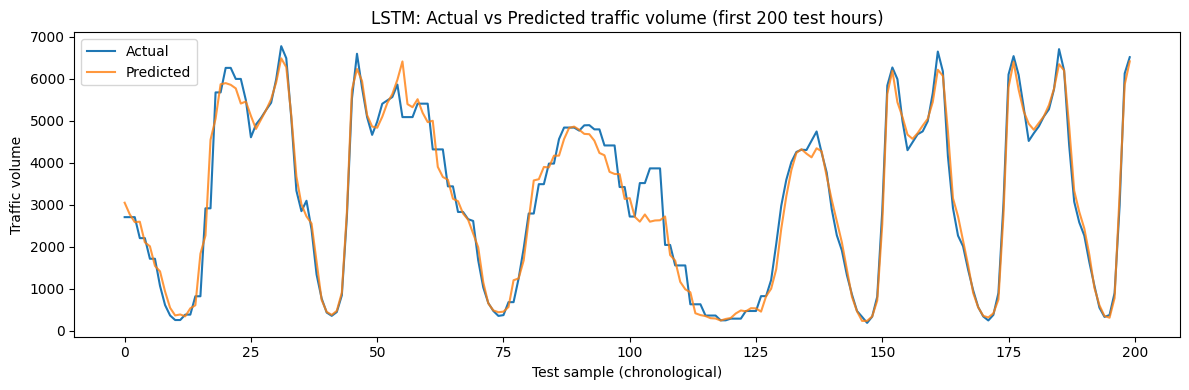

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual[:200], label="Actual", linewidth=1.5)
plt.plot(y_pred_actual[:200], label="Predicted", linewidth=1.5, alpha=0.8)
plt.xlabel("Test sample (chronological)")
plt.ylabel("Traffic volume")
plt.title("LSTM: Actual vs Predicted traffic volume (first 200 test hours)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Explainability: SHAP on the Random Forest Regressor (proxy for the LSTM)

### 5.1 Rebuild the Task 1 feature set and re-train the Random Forest

In [9]:
# --- Same feature set as Task 1's models.py (traffic_volume and anything derived from it excluded) ---
is_holiday = df["holiday"].notna() & (df["holiday"] != "None")
df["is_holiday"] = is_holiday.astype(int)

time_features = [
    "hour", "day_of_week", "is_weekend",
    "hour_sin", "hour_cos", ]
exclude_raw_text = {"weather_main", "weather_description"}
weather_onehot = sorted(
    c for c in df.columns if c.startswith("weather_") and c not in exclude_raw_text
)
weather_derived = [
    "is_precipitation", "total_precipitation", "is_overcast",
    "is_clear", "is_severe_weather", "clouds_all", "temp_c",
]
feature_cols = time_features + weather_onehot + weather_derived + ["is_holiday"]

rf_data = df[feature_cols + ["traffic_volume"]].dropna()
X_rf = rf_data[feature_cols]
y_rf = rf_data["traffic_volume"]

X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=RANDOM_STATE
)

rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_rf_train, y_rf_train)

rf_mae = mean_absolute_error(y_rf_test, rf_model.predict(X_rf_test))
rf_r2 = r2_score(y_rf_test, rf_model.predict(X_rf_test))
logger.info("Random Forest (explainability proxy) — MAE: %.2f, R2: %.4f", rf_mae, rf_r2)
#logger.info(f"Random Forest (proxy for explainability) — MAE: {rf_mae:.2f}, R2: {rf_r2:.4f}")

2026-09-23 22:26:57 | INFO | task3_models | Random Forest (explainability proxy) — MAE: 263.71, R2: 0.9480


### 5.2 Global explanation: SHAP summary plot

2026-09-23 22:33:46 | INFO | task3_models | SHAP values computed on 2000 sampled test rows


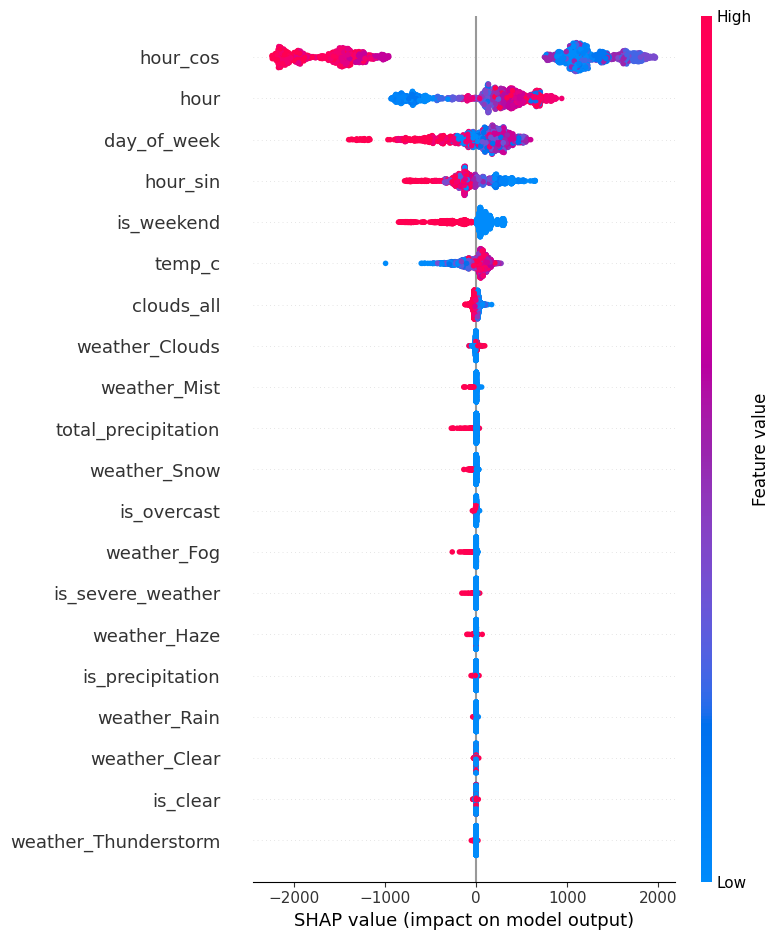

In [10]:
explainer = shap.TreeExplainer(rf_model)

# Sample for speed — SHAP on the full ~48k-row test set is unnecessarily slow for TreeExplainer's exact computation
X_shap_sample = X_rf_test.sample(n=min(2000, len(X_rf_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap_sample)
logger.info("SHAP values computed on %s sampled test rows", len(X_shap_sample))

shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.tight_layout()
plt.show()

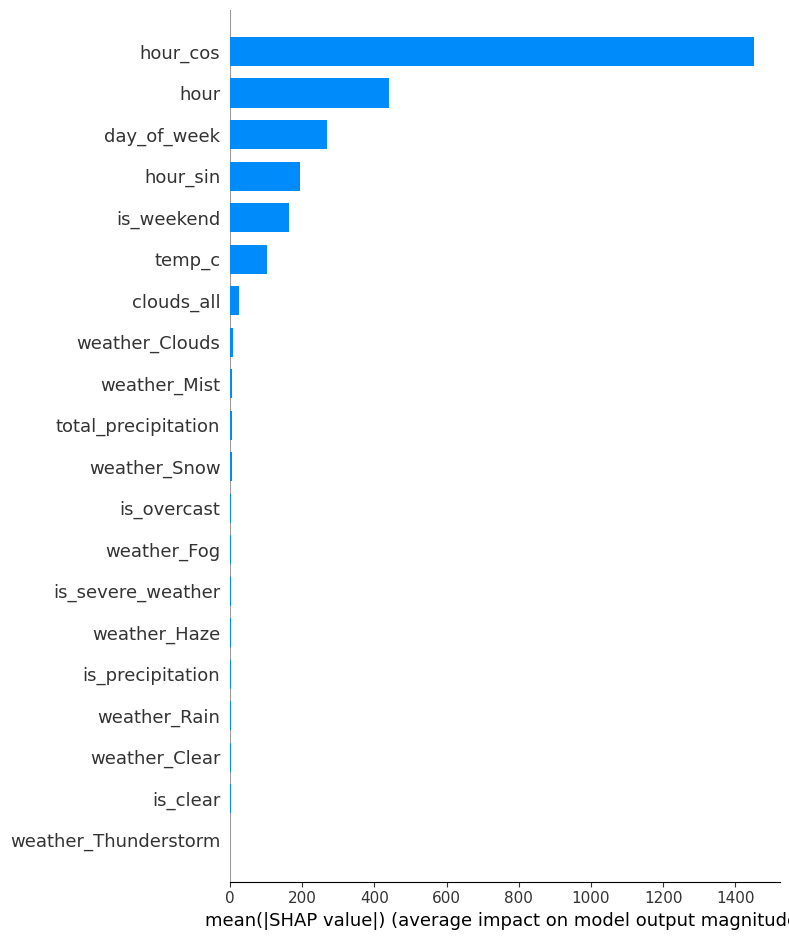

In [11]:
# Mean |SHAP value| per feature — a simpler, ranked bar-chart view of the same information
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

### 5.3 Local explanation: one individual prediction

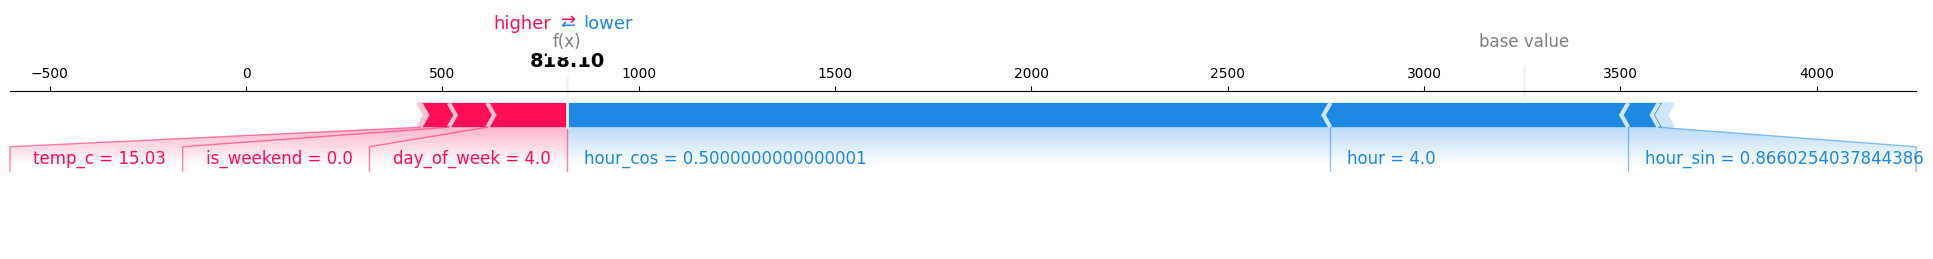

2026-09-23 22:33:49 | INFO | task3_models | SHAP local force-plot generated for one example row


In [12]:
row_idx = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[row_idx],
    X_shap_sample.iloc[row_idx],
    matplotlib=True,
    show=False,
)
plt.tight_layout()
plt.show()
logger.info("SHAP local force-plot generated for one example row")

## 6. Summary

- **LSTM** (sequential, 24-hour lookback, multivariate): report the MAE/R² from section 4.3 here, and compare against the Random Forest Regressor's MAE 263.67 / R² 0.9480 from Task 1.The LSTM predicts from a rolling window of recent history while the Random Forest predicts from instantaneous features, but both target the same `traffic_volume` quantity.
- **Explainability**: from the SHAP summary plot, name the top 2–3 features driving traffic volume predictions in the Random Forest proxy model, and note the direction of their effect (e.g. does higher cloud cover push predictions up or down?).


In [13]:
# 1. Save the keras model
model.save("my_model.keras")